[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScriptsRemote/Transcend_SummerSchool/blob/main/Day2_Hydroeconomics_and_Water_Mapping/02_sensors_and_spectral_behaviour.ipynb)

# Day 2 - Hydroeconomics & Water Mapping
## Session 2: Sensors and Spectral Behaviour

| | |
|---|---|
| **Fecha / Date** | 2026-10-13 (Tuesday / Martes) |
| **Horario / Time** | 10:40 - 12:10 |
| **Entidad / Entity** | SEI / IMDEA |
| **Instructores / Instructors** | Christhian, Sebastian |

### Contenido / Content

> Data acquisition and sensor systems. Spatial, spectral, radiometric and temporal resolution (Landsat, Sentinel, MODIS). Spectral behaviour of vegetation, soil and water

### Objetivos de aprendizaje / Learning objectives

- [ ] Explain the four resolutions of a remote sensing system (spatial, spectral, temporal, radiometric) and the trade-offs between them
- [ ] Connect to Google Earth Engine from Python (`ee` + `geemap`) and define an area of interest interactively on a map
- [ ] Build and interpret natural-colour and false-colour composites for Landsat 8, MODIS and Sentinel-2
- [ ] Compare the same target on the same date across three sensors and explain the differences from their resolutions

### Datos necesarios / Required data

No local files are needed: all imagery is streamed from the Google Earth Engine catalogue.
A **free Earth Engine account** is required (see section 2.2).

| Collection | Product | Used for |
|---|---|---|
| `LANDSAT/LC08/C02/T1_L2` | Landsat 8 Surface Reflectance | 30 m composites |
| `MODIS/061/MOD09A1` | MODIS Terra Surface Reflectance, 8-day | 500 m composites |
| `COPERNICUS/S2_SR_HARMONIZED` | Sentinel-2 Surface Reflectance | 10-20 m composites |

---


## 2.1 - Teoria / Theory

###  What is remote sensing?
Remote sensing is the **practice of obtaining information** about the Earth's surface by means of images
acquired from space, using reflected or emitted electromagnetic radiation, in one or more regions of the
electromagnetic spectrum. 

Remote sensing images can be produced by sensors on board orbital platforms (satellites) and airborne platforms (aeroplanes and UAVs), which capture the electromagnetic radiation leaving the Earth's surface towards space. This information is extremely important for models of precipitation, pollution, anthropisation and vulnerability to disasters, mainly because it is not point-based, constituting a continuous source of data over large areas.

With the advent of photography and photogrammetry, human beings sought various ways of obtaining a view from above the Earth's surface — using balloons, pigeons, aeroplanes and rockets, as the examples below show. This change of perspective was fundamental in overcoming our visual limitations on the ground, allowing large areas to be mapped and giving a new understanding of geographical space. It was precisely this growing need to monitor the Earth continuously, comprehensively and accurately that drove technological advances until we reached the modern science of remote sensing.

a) <img src="https://infoportugal.pt/wp-content/uploads/2020/03/Pombos_Camara.jpg" width="500"> b)<img src="https://nypost.com/wp-content/uploads/sites/2/2014/06/wwi-anniversary_-3.jpg?resize=768,1024&quality=90&strip=all" width="200">

Fig 1 - a) Acquisition of aerial images using pigeons in 1907 - Dr. Julius Neubronner and b) An aerial photo shows trenches on the Western Front on June 17, 1917

Modern remote sensing began in 1972, with the launch of the first imaging satellite of the Landsat series by the United States government. This satellite carried on board the Multispectral Scanner System (MSS) sensor, with digital images in four spectral bands and 80 m pixels (Zanota et al, 2019). Once the great potential associated with the periodic observation of large areas of the Earth's surface had been recognised, other countries began to run space programmes and to launch ever more advanced satellites. Today, satellites
are able to acquire images in tens or hundreds of spectral bands, with pixel sizes ranging from a few centimetres to kilometres, depending on the application for which they are intended.

<div style="width:200px">

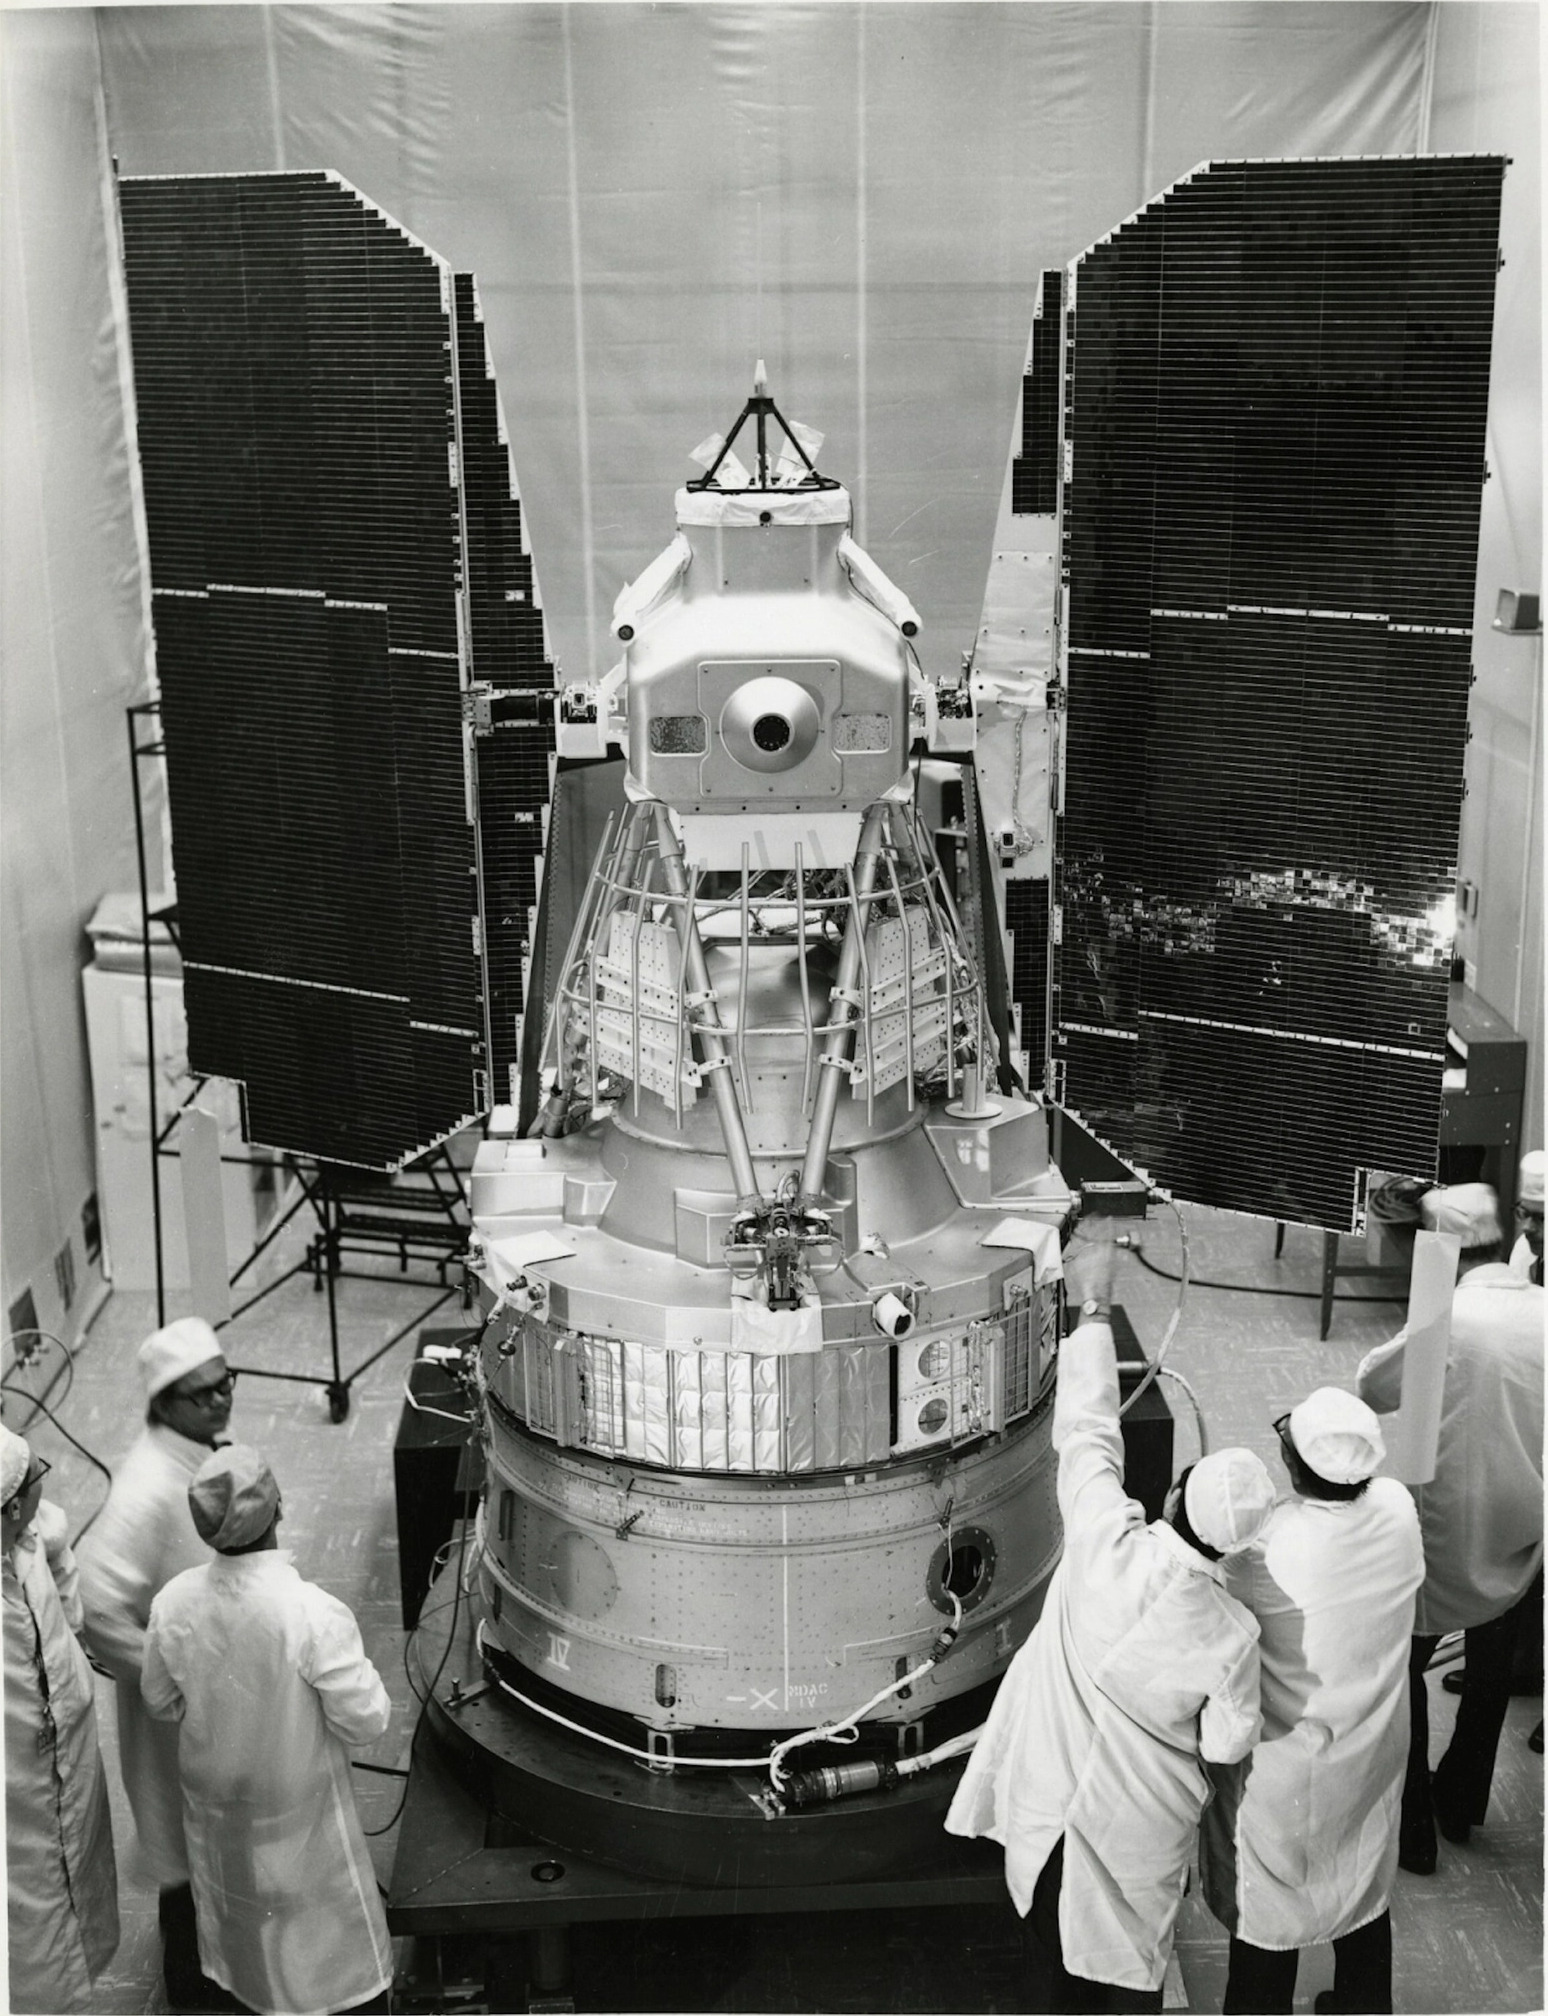

</div>

Fig 2 - Landsat 1 in flight configuration with solar panels deployed after tests at the G.E. Valley Forge Plant, 1972.

As Baptista (2023) points out, besides Landsat 1 other satellites in this series were launched, and it is considered the most widely exploited system, with the largest number of papers
published from its data to date. Of them all, only number 6 obtained no images, as it became inoperative after its launch. 

<video src="https://usgs-ocapsv2-public-output-media.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/l8swath/MP4/l8swath.mp4"
       width="600" controls loop muted playsinline></video>

Fig 3 - Image acquisition by Landsat - representation

Although fundamental, optical sensors (such as those of the Landsat series) depend on sunlight and cannot record the surface when the sky is overcast. To overcome the problem of clouds, remote sensing also uses active systems, such as Synthetic Aperture Radar (SAR). Instead of depending on illumination from the Sun, a satellite carrying a radar emits its own pulse of energy in the microwave range and measures the signal that is reflected back from the surface. This allows images to be acquired both by day and by night, regardless of weather conditions.

<div style="display:flex; gap:12px; align-items:flex-start; text-align:center">
  <div style="flex:1">
    <img src="https://earthdata.nasa.gov/s3fs-public/styles/hds_large/public/2022-02/SARPolarization.jpg?VersionId=KyQ7vrmGXFfSLVdRu6r8oMCEiSy.uiuu&itok=TPctruIs" style="width:100%; height:180px; object-fit:contain">
    <br><small>(a) Scattering mechanisms: rough surface, volume and double bounce</small>
  </div>
  <div style="flex:1">
    <img src="https://earthdata.nasa.gov/s3fs-public/styles/hds_large/public/imported/SARtree_figure2.jpg?VersionId=39oxzCRneDXVdpdJUtc_MO.Rgwnr4cDd&itok=_u1-xSiS" style="width:100%; height:180px; object-fit:contain">
    <br><small>(b) Canopy penetration by wavelength (X, C, L, P bands)</small>
  </div>
  <div style="flex:1">
    <img src="https://earthdata.nasa.gov/s3fs-public/2023-01/sentinel-1_sar_turkey.jpg?VersionId=0QoLtC45D9C7RcRFoQp80j7I.z6eVJmH" style="width:100%; height:180px; object-fit:contain">
    <br><small>(c) Sentinel-1 acquisition, C band</small>
  </div>
</div>

Fig 4 - How SAR interacts with the surface: the scattering mechanism that returns the signal (a), how far each wavelength penetrates the canopy (b), and the resulting image from an operational C-band sensor (c). Source: NASA Earthdata.

Different missions based on SAR technology play essential roles in Earth observation. The **SRTM mission**, for example, used synthetic aperture radars to map elevation and relief on a global scale. Satellites such as the **Japanese ALOS** brought great advances to land cover monitoring using this same technology, while the current European **Sentinel-1** constellation provides continuous SAR data, applied to everything from flood detection to agricultural monitoring. Development continues to advance with a focus on specific themes, as in the case of the future **Biomass** mission, designed with a radar operating at a frequency capable of measuring the structure and volume of global forest biomass.

<div style="display:flex; gap:10px; align-items:flex-start; text-align:center">
  <div style="flex:1">
    <img src="https://www.arcgis.com/sharing/rest/content/items/011a9efe78804f18bd002efe90956994/info/thumbnail/ago_downloaded.jpg?w=800" style="width:100%;object-fit:contain">
    <br><small>(a) SRTM - C band</small>
  </div>
  <div style="flex:1">
    <img src="https://earthdata.nasa.gov/s3fs-public/styles/hds_hero_half/public/2024-10/alos-palsar-project-hero-1.jpg?VersionId=rOfotItYGoqhXz7lpFEcsol8LKL0qZeK&itok=_3YzYygc" style="width:100%;object-fit:contain">
    <br><small>(b) ALOS PALSAR - L band</small>
  </div>
  <div style="flex:1">
    <img src="https://www.esa.int/var/esa/storage/images/esa_multimedia/images/2025/02/seeing_the_wood_through_the_trees/26571714-1-eng-GB/Seeing_the_wood_through_the_trees_pillars.png" style="width:100%">
    <br><small>(c) Biomass - P band</small>
  </div>
</div>

Fig 5 - SAR missions and bands of the microwave spectrum: the longer the wavelength, the greater the penetration into the canopy. Sources: Esri/NASA JPL (SRTM), NASA Earthdata/JAXA (ALOS PALSAR), ESA/ATG medialab CC BY-SA 3.0 IGO (Biomass).

Finally, besides the continuous advance of optical and radar satellites, sensor technology has been reduced in size and weight, allowing sensors to operate much closer to the ground. This is where **Unmanned Aerial Vehicles (UAVs or drones)** come in. While satellites guarantee continuous observation of large stretches of land, drones complement this work at the local level. They offer spatial resolution of the order of centimetres and the flexibility to fly on the exact day and at the exact time the data is needed, making them indispensable tools for precision mapping.

<img src="https://media.licdn.com/dms/image/v2/C4D22AQHkakNimUnaVA/feedshare-shrink_800/feedshare-shrink_800/0/1663874568242?e=2147483647&v=beta&t=8fwlPqN_G_eNkxQrwSyBo2eu1so2S6I8mp-tZPrZ210" width="600">

Fig 5 - NDVI by field plot using drone images.

### What a sensor actually records

In remote sensing for Earth observation, sensor systems were designed to offer images with distinct geometric, spectral and temporal characteristics. These data are collected by recording the **electromagnetic radiation (EMR)** reflected or emitted by the target on the Earth's surface at **different wavelengths** of the **electromagnetic spectrum**. Remote sensors are able to capture the spectral responses of different regions of the electromagnetic spectrum, far more than the human eye can see (visible light).

The energy emanating from the surface may come from the intense reflection of the sunlight that illuminates terrestrial targets (passive reflective remote sensing) or from the direct emission of thermal radiation by materials at the surface (passive emissive remote sensing). A remote sensing image may also originate from the reflection of the **artificial energy** produced by the satellite itself, which was directed at the surface and then captured by the sensor, as occurs in **radar images** (Radio Detection and Ranging) or **Lidar** (Light Detection and Ranging), which fall under active remote sensing.

Solar radiation, travelling through the vacuum until it reaches the Earth, **first strikes the outermost region of the atmosphere**, called the **top of the atmosphere**. From that point on, the radiation begins to **interact** with various atmospheric constituents, being **absorbed**, ****scattered** and **reflected** by gases such as oxygen and ozone, water vapour, carbon dioxide and particles of different sizes. Once in contact with the **surface**, the radiation may be absorbed or reflected back into space. The type of interaction depends both on the chemical and physical composition of the target and on the wavelength of the incident radiation. 

In the example below we can see the process of data collection at orbital level from an imaging sensor. Part of the **solar radiation** striking the Earth's surface is **reflected** back into space and is **captured by the satellite's sensor**. The image data are redirected by telemetry to receiving stations located at the surface, where they are pre-processed and made available to users. One of the main products of remote sensing, **digital images**, are formed by sets of pixels (picture elements)
that describe the amount of energy leaving a defined portion of the surface. What is meant here by energy is nothing more than distinct forms of **wave or electromagnetic radiation**. All **electromagnetic radiation** has fundamental properties and predictable behaviours according to physical theory. It is through prior
knowledge of these interactions that one can **interpret the targets at the surface** on the basis of the **amount of radiation that was reflected or emitted** by them.

<img src="https://cdn-fnoci.nitrocdn.com/ThwtfMtLrzDTNYOmsRitVsOalzfIZLRK/assets/images/optimized/rev-441541a/i0.wp.com/geolearn.in/wp-content/uploads/2022/09/9752c29b48640038080ec50e60b23dad.Remote-Sensing-Process.jpg" width="600">

Fig 6 - Remote sensing data acquisition and processing.
Source:(Lucrêncio et al, 2021).

The diversity of radiation produced by the Sun is commonly classified into specific wavelength ranges that share similar characteristics of interaction with matter or of practical application on Earth. This classification is **called the electromagnetic spectrum**, and its division is subjective and may vary depending on the application and the reference used.

The **electromagnetic spectrum** is a way of representing, in an ordered fashion, the main regions of radiation as a function of their wavelengths. They begin with cosmic rays, gamma rays and X-rays, all with lengths of the order of the picometre (pm) or 10-12m. Then comes the ultraviolet region, followed by the **region of visible light and the infrared**, which are expressed in **nanometres (nm)** or 10-9m and in **micrometres (µm)** or 10-6m. From the microwaves onwards, wavelengths are expressed in millimetres (mm) or 10-3m, and radio waves range
from the metre (m) to the kilometre (km). 

<img src="https://b3801007.assetcdn.net/3801007/wp-content/uploads/2022/06/electromagnetic-EM-spectrum.png?lossy=2&strip=1&webp=1" width="600">

Because of the different **chemical and physical composition** of the targets at the Earth's surface, it is natural for materials to display **diverse behaviours towards electromagnetic radiation**. For a single material, **absorption, transmission and reflection in varying amounts** may occur simultaneously, for example, depending
on the combination of the elements that make it up. Therefore, if each material displays a **unique behaviour** towards incident radiation, then it is possible to identify its chemical composition from it.

The chart below illustrates the **spectral signature of different surfaces**, showing how they **absorb or reflect radiation across the wavelengths**. The **vegetation curve** stands out in the visible spectrum through its strong absorption in the blue and red ranges, energy consumed by chlorophyll pigments during photosynthesis, which makes it **reflect predominantly in the green**. On reaching the near infrared, the plant's reflectance undergoes a dramatic jump, because the internal cell structure of **healthy leaves** scatters and reflects that radiation, invisible to our eyes, intensely. Further along, in the **shortwave infrared**, deep drops in reflection are observed; these absorption "valleys" occur because the **moisture (water) contained in plant tissues strongly retains the energy**. In sharp contrast, a pure water surface absorbs practically all the incident radiation, reducing its reflection to zero right at the start of the infrared. On the other hand, **mineral targets such as sand and dry soil** display a gradual and steady increase in reflectance across the whole spectrum, lacking the abrupt drops caused by water in vegetation, while urban areas show an intermediate and more irregular reflective behaviour.

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-018-27905-0/MediaObjects/41598_2018_27905_Fig11_HTML.jpg?as=webp" width="400">

Fig 7 - Reflectance of water, vegetation, soil and urban residential in the 0.4–2.5 μm spectrum.
Source: Pan et al (2018)

Spectral bands (or spectral channels) are the **segments of the electromagnetic spectrum** for which the sensors on board satellites are designed to acquire images. Despite the **extent of the electromagnetic spectrum**, few regions are used in remote sensing applications – only those in which the radiation is not absorbed by the Earth's atmosphere and those in which the sensors have sensitivity receive practical applications. 

---

### Resolutions of satellite images

The images produced by imaging sensors have different resolutions, which influence the detection or identification of an object. They are: 
* spatial resolution
* spectral resolution
* radiometric resolution 
* temporal resolution.

### 1. Spatial resolution - *how small is the smallest thing I can see?*

Spatial resolution “refers to the ability of the sensor system to distinguish and measure targets”.
It is an important parameter, since it determines the size of the smallest object that can be detected in the image, directly related to the pixel. The **smaller the pixel size**, the **higher the spatial resolution of the image**, since the greater the detail of the objects that can be seen for the same area.

The ground area represented by one pixel:

- Landsat 8/9 OLI: **30 m** (a pixel covers 900 m2, roughly a football penalty area)
- Sentinel-2 MSI: **10 m** in the visible/NIR, **20 m** in the red-edge and SWIR
- MODIS: **250 m / 500 m / 1000 m** depending on the band

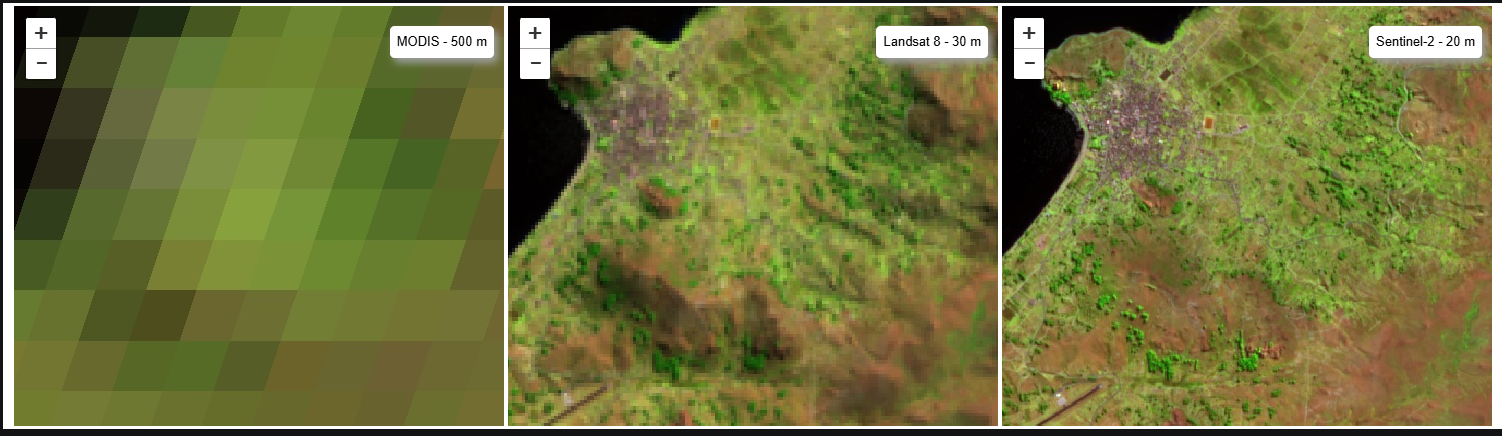

Fig 8 - Different spatial resolutions

Practical rule: to *detect* an object reliably you want it to be at least **2-3 pixels
wide**. A 20 m wide irrigation canal is invisible at 500 m (MODIS), a mixed signal at 30 m
(Landsat) and detectable at 10 m (Sentinel-2). Anything smaller than one pixel produces a
**mixed pixel**: the recorded value is the weighted average of water, soil and vegetation
inside that cell, which is the single most common source of error in small-reservoir mapping.

### 2. Spectral resolution - *how many colours, and how narrow?*

The number of bands and the width of each one. More and narrower bands mean a finer
description of the surface, at the price of less energy per band.

- Landsat 8: 9 reflective bands (coastal, blue, green, red, NIR, 2 SWIR, pan, cirrus) + 2 thermal
- Sentinel-2: 13 bands, including 3 **red-edge** bands that Landsat does not have -
  the red-edge is where vegetation stress shows up first
- MODIS: 36 bands, designed for global atmosphere/ocean/land monitoring rather than fine mapping

The chart below illustrates the technical relationship between atmospheric transmittance and the strategic positioning of the spectral bands of different orbital sensors. The background area represents the "atmospheric windows"

<img src="https://pbs.twimg.com/media/Cr2V5GJUAAAU6DX?format=jpg&name=large" width="600">

Fig 9 - Approximate spectral bands comparison chart for Landsat,MODIS and Sentinel2.

Source: USGS (2016)

### 3. Temporal resolution - *how often do I get a new image?*

The revisit interval of the same point on the ground.

- Landsat 8 alone: **16 days**; combining Landsat 8 + 9 gives **~8 days**
- Sentinel-2 A + B: **~5 days** at the equator, 2-3 days at mid latitudes
- MODIS: **1-2 days** (which is why 8-day and 16-day composites are the standard products)
 - GOES / Meteosat (Geostationary): 10 to 15 minutes. Positioned at ~36,000 km, they stare at the same hemisphere continuously, sacrificing spatial detail (1-2 km) for real-time monitoring.

For hydrology and disaster management, this scale is decisive. A rapid flash flood or a sudden fire ignition might simply not exist in a 16-day Landsat archive. MODIS will see the daily progression at 500 m, while a geostationary sensor like GOES will capture the exact hour the event started, albeit at a much coarser resolution. Add cloud cover, and the effective revisit for optical sensors becomes much longer than the nominal one.

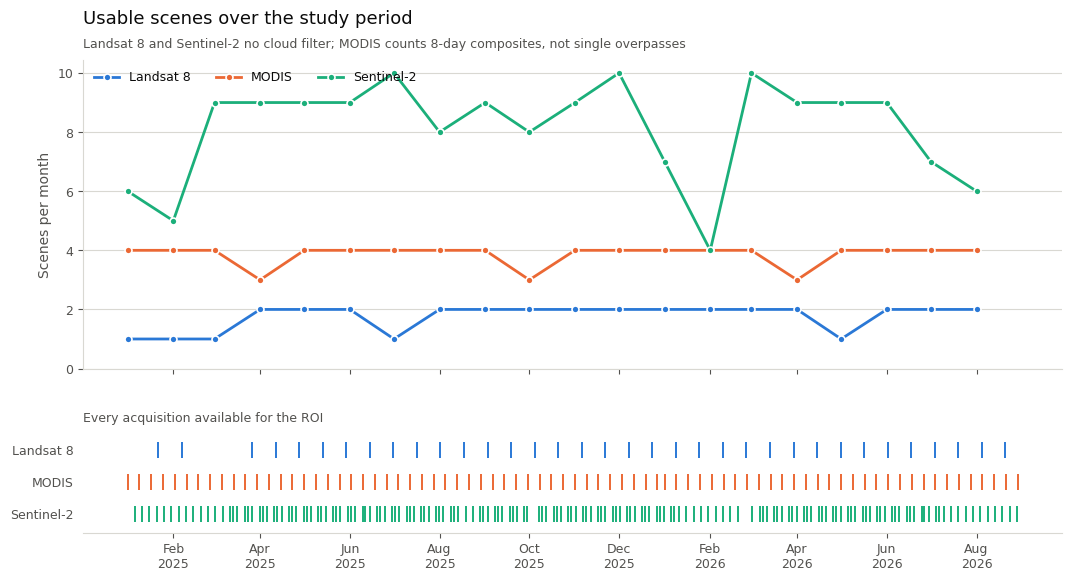

Fig 10 - Example of the images available for the same area using Landsat,MODIS and Sentinel2.


### 4. Radiometric resolution - *how many shades can I distinguish?*

Also known as quantization, the radiometric resolution of an image can be understood as the sensor's ability to record different gray levels. Each pixel can take on values ​​ranging from black to white, with the specific level determined by the amount of radiation coming from the surface. The more gray levels an image displays, the higher (or better) its radiometric resolution. This refers to the number of levels used to quantize the signal, expressed in bits.

| Bits | Levels | Example |
|---|---|---|
| 8 bit | 256 | Landsat 5 TM (legacy) |
| 12 bit | 4096 | Landsat 8 OLI, Sentinel-2 MSI, MODIS |
| 16 bit | 65536 | storage format of the Collection 2 products |

Higher radiometric resolution means subtle contrasts survive: dark targets such as **water**
and **shadow** occupy the very bottom of the range, so the 12-bit OLI separates turbid from
clear water where the old 8-bit TM saturated everything to near zero.

> Because values are stored as scaled integers, **every product must be rescaled to physical
> reflectance (0-1) before use**. Landsat Collection 2 L2 uses `0.0000275 * DN - 0.2`;
> MODIS MOD09A1 and Sentinel-2 L2A use `DN * 0.0001`. We do this in every block below.

---

### Comparative summary

| | **Landsat 8/9 (OLI)** | **Sentinel-2 (MSI)** | **MODIS (Terra/Aqua)** |
|---|---|---|---|
| Spatial | 30 m (15 m pan) | 10 / 20 / 60 m | 250 / 500 / 1000 m |
| Spectral | 9 reflective + 2 thermal | 13 bands (incl. red-edge) | 36 bands |
| Temporal | 16 d (8 d with both) | ~5 d | 1-2 d |
| Radiometric | 12 bit | 12 bit | 12 bit |
| Swath | 185 km | 290 km | 2330 km |
| Archive | 1972 (Landsat 1) / 2013 (L8) | 2015 | 2000 |
| Best for | long time series, medium detail | field-scale detail, crop monitoring | large-scale, high-frequency dynamics |

**The trade-off in one line:** MODIS sees *everything, often, coarsely*; Sentinel-2 sees
*a lot of detail, less often*; Landsat sits in between and, crucially, has the **longest
archive** - which is why it remains the reference for multi-decadal change.

---

### Band composition - why we combine three bands

A screen can only display three channels (Red, Green, Blue). A **composite** assigns one
spectral band to each channel. Changing the assignment changes what the image emphasises,
without changing the data at all.

| Composite | Channels (R-G-B) | Landsat 8 | Sentinel-2 | MODIS (MOD09A1) | What it highlights |
|---|---|---|---|---|---|
| Natural colour | Red - Green - Blue | B4-B3-B2 | B4-B3-B2 | b01-b04-b03 | the scene as the eye would see it |
| False colour (NIR) | NIR - Red - Green | B5-B4-B3 | B8-B4-B3 | b02-b01-b04 | **vegetation in bright red**, water almost black |
| False colour (SWIR) | SWIR - NIR - Red | B6-B5-B4 | B11-B8-B4 | b06-b02-b01 | **moisture and water bodies**, burnt areas, bare soil |

<img src="https://gsp.humboldt.edu/olm/Courses/GSP_216/images/bands.jpg" width="600">

Fig 12 - Composite Bands.

### Spectral behaviour of vegetation, soil and water

The reason those composites work is that the three main surfaces have very different
reflectance curves:

- **Healthy vegetation** - low in blue and red (chlorophyll absorbs them), a small peak in
  green (hence our perception of "green"), a **very steep rise into the NIR** caused by the
  internal leaf structure, then dips in the SWIR where leaf water absorbs. The NIR/Red
  contrast is the basis of NDVI.
- **Bare soil** - a smooth curve that **increases gradually** from blue to SWIR, with no NIR
  jump. Brightness depends on moisture (wetter = darker) and on iron/organic content.
- **Water** - reflects a little in the blue/green and then **absorbs almost everything from
  the NIR onwards**, so it appears black in NIR and SWIR. This near-zero NIR response is what
  makes water so easy to isolate (NDWI, MNDWI - session 3). Sediment or algae raise the
  visible part of the curve and are the basis of water-quality proxies.

Keep this in mind while looking at the composites below: the false-colour images are simply
a visual way of reading these three curves.


<a href="https://www.youtube.com/watch?v=A6WzAc1FTeA" target="_blank" rel="noopener"
   style="position:relative; display:inline-block">
  <img src="https://img.youtube.com/vi/A6WzAc1FTeA/hqdefault.jpg" width="600">
  <span style="position:absolute; top:50%; left:50%; transform:translate(-50%,-50%);
               font-size:48px; color:#fff; text-shadow:0 2px 8px rgba(0,0,0,.6)">&#9654;</span>
</a>

Fig 13 - Example Composite bands: YouTube (click to watch).



## 2.2 - Practica guiada / Guided hands-on

### Step 1 - Google Earth Engine account and Python setup

Earth Engine is free for research and education, but it requires a **registered account
linked to a Google Cloud project**. Do this once, before the session:

1. Create (or use) a Google account.
2. Register at **<https://code.earthengine.google.com/register>** and choose
   *Use with a Cloud Project* -> *Unpaid usage* -> *Academia & Research*.
3. Either create a new Cloud project or pick an existing one. The project id is what
   `ee.Initialize(project=...)` needs - in this notebook we use **`ee-christhianscunha`**;
   **replace it with your own project id**.
4. Check that your account works by opening the Code Editor: <https://code.earthengine.google.com/>

Useful links:

- Registration: <https://code.earthengine.google.com/register>
- Data catalogue: <https://developers.google.com/earth-engine/datasets>
- Python API guide: <https://developers.google.com/earth-engine/guides/python_install>
- geemap documentation: <https://geemap.org>

> **`ee` vs `geemap`** - `ee` is the official client library: it *describes* the computation
> and sends it to Google's servers, which do the processing. `geemap` is a community package
> that puts an interactive Leaflet/Folium map on top of it, so we can draw geometries and
> add layers with one line.


In [ ]:
# ---------------------------------------------------------------------------
# Install the libraries (only needed once per runtime, e.g. in Google Colab)
# ---------------------------------------------------------------------------
# Locally you would run this in a terminal:  pip install earthengine-api geemap
#%pip install -q earthengine-api geemap

import ee, geemap
print("Libraries already available - ee", ee.__version__)
print("Installed - geemap", geemap.__version__)

In [ ]:
# ---------------------------------------------------------------------------
# Authenticate and initialise Earth Engine
# ---------------------------------------------------------------------------
import ee
import geemap

# >>> REPLACE with your own Cloud project id if you are not using this one <<<
EE_PROJECT = "ee-christhianscunha"

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

# Small server-side call to confirm the connection really works
print("Earth Engine connected")
print("Project        :", EE_PROJECT)

### Step 2 - The interactive map

`geemap.Map()` creates an interactive map inside the notebook. It gives us three things we
will use throughout the week:

- **basemaps** for context (satellite, terrain, OpenStreetMap);
- **drawing tools** on the left toolbar (marker, polyline, polygon, rectangle) - whatever you
  draw is stored in `Map.user_roi` / `Map.user_rois` and becomes available in Python;
- **`Map.addLayer()`**, which renders an Earth Engine image *on the fly* - the pixels are
  computed on Google's servers only for the tiles you are looking at.

> **Your turn:** use the **marker tool** on the map below to place a point over an area you
> want to inspect (an irrigated field, a reservoir, a stretch of river). If you draw nothing,
> the next cell falls back to a default point over **Copacabana, Lake Titicaca (Bolivia)**.


In [ ]:
# ---------------------------------------------------------------------------
# Interactive map - draw your point here (marker tool on the left toolbar)
# ---------------------------------------------------------------------------
# Default view: Copacabana, Lake Titicaca (Bolivia) - lake, irrigated terraces
# and bare soil in the same scene, ideal to compare spectral behaviour.
DEFAULT_LON, DEFAULT_LAT = -69.0866, -16.1660

Map = geemap.Map(center=[DEFAULT_LAT, DEFAULT_LON], zoom=11)
Map.add_basemap("SATELLITE")   # high-resolution reference to help you choose a target

Map

### Step 3 - Turning what you drew into a geometry

`Map.user_roi` returns the **last** geometry drawn on the map as an `ee.Geometry`
(`Map.user_rois` returns all of them as a FeatureCollection). If nothing was drawn it is
`None`, so we always provide a fallback - this keeps the notebook runnable end-to-end.

A **point** is enough to *filter* image collections (`filterBounds` keeps every scene that
contains it), but it cannot be used to *clip* or to set the map extent. So we also build a
small square around it (`buffer` + `bounds`), which we call the **AOI**, used only for
display.


In [ ]:
# ---------------------------------------------------------------------------
# Extract the region of interest (ROI) from the map, with a safe fallback
# ---------------------------------------------------------------------------
DEFAULT_POINT = ee.Geometry.Point([DEFAULT_LON, DEFAULT_LAT])

if Map.user_roi is not None:
    roi = Map.user_roi                      # geometry drawn by the user
    print("Using the geometry you drew on the map.")
else:
    roi = DEFAULT_POINT                     # fallback so the notebook always runs
    print("No geometry drawn -> using the default point (Copacabana, Bolivia).")

# Centroid in [lon, lat], useful later for centring maps and charts
CENTER_LON, CENTER_LAT = roi.centroid(maxError=1).coordinates().getInfo()

# AOI = 8 km square around the ROI, used ONLY to clip and frame the displays
AOI = roi.buffer(8000).bounds()

print("ROI type       :", roi.type().getInfo())
print("ROI centroid   : lon = {:.4f}, lat = {:.4f}".format(CENTER_LON, CENTER_LAT))
print("AOI area (km2) : {:.1f}".format(AOI.area(maxError=1).divide(1e6).getInfo()))

# Show the ROI and the AOI on the map
Map.addLayer(AOI, {"color": "yellow"}, "AOI (8 km buffer)")
Map.addLayer(roi, {"color": "red"}, "ROI (analysis point)")
Map.centerObject(AOI, 11)

In [ ]:
# ---------------------------------------------------------------------------
# Shared parameters and small helpers reused by the three sensors
# ---------------------------------------------------------------------------
START = "2025-01-01"   # study period: from January 2025 ...
END   = "2026-09-01"   # ... to September 2026

---

## 2.3 - Landsat 8 Surface Reflectance (30 m)

**Collection:** `LANDSAT/LC08/C02/T1_L2` - Collection 2, Level 2 (atmospherically corrected
surface reflectance), Tier 1 (best geometric and radiometric quality).

The workflow is always the same, and we will repeat it for the other two sensors:

1. **filter** - by area (`filterBounds`), by date (`filterDate`) and by metadata (cloud cover);
2. **mask** - remove cloud, shadow, cirrus and snow pixels using the `QA_PIXEL` quality band;
3. **rescale** - convert the stored integers to reflectance (0-1);
4. **composite** - reduce the time series to one image (here the median, which is robust to
   the few cloudy pixels that survive the mask);
5. **display** - natural colour and false colour.

**Landsat 8 OLI bands used here**

| Band | Name | Wavelength | Resolution |
|---|---|---|---|
| SR_B2 | Blue | 0.45-0.51 um | 30 m |
| SR_B3 | Green | 0.53-0.59 um | 30 m |
| SR_B4 | Red | 0.64-0.67 um | 30 m |
| SR_B5 | NIR | 0.85-0.88 um | 30 m |
| SR_B6 | SWIR-1 | 1.57-1.65 um | 30 m |
| SR_B7 | SWIR-2 | 2.11-2.29 um | 30 m |


In [ ]:
# ---------------------------------------------------------------------------
# Landsat 8 - cloud mask and scaling
# ---------------------------------------------------------------------------
def mask_and_scale_l8(img):
    # QA_PIXEL is a bitmask: each bit flags one condition for every pixel
    qa = img.select("QA_PIXEL")
    cirrus = qa.bitwiseAnd(1 << 2).eq(0)   # bit 2 = cirrus
    cloud  = qa.bitwiseAnd(1 << 3).eq(0)   # bit 3 = cloud
    shadow = qa.bitwiseAnd(1 << 4).eq(0)   # bit 4 = cloud shadow
    snow   = qa.bitwiseAnd(1 << 5).eq(0)   # bit 5 = snow / ice
    clear  = cirrus.And(cloud).And(shadow).And(snow)

    # Collection 2 L2 scaling: reflectance = DN * 0.0000275 - 0.2
    optical = img.select("SR_B.").multiply(0.0000275).add(-0.2)

    return (optical.updateMask(clear)
                   .copyProperties(img, ["system:time_start", "CLOUD_COVER"]))

l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .filterBounds(roi)                        # scenes containing our point
        .filterDate(START, END)                   # study period
        .filter(ee.Filter.lt("CLOUD_COVER", 40))  # discard very cloudy scenes
        .map(mask_and_scale_l8))

l8

In [ ]:
# Median composite: for each pixel, the median of all valid observations
l8_median = l8.median().clip(AOI)

# ---------------------------------------------------------------------------
# Landsat 8 - natural colour and false colour composites
# ---------------------------------------------------------------------------
# After rescaling, surface reflectance ranges from 0 to ~1; land targets rarely
# exceed 0.35, so we stretch 0 - 0.3 to use the full display range.
l8_rgb   = {"bands": ["SR_B4", "SR_B3", "SR_B2"], "min": 0, "max": 0.3}  # R-G-B
l8_nir   = {"bands": ["SR_B5", "SR_B4", "SR_B3"], "min": 0, "max": 0.3}  # NIR-R-G
l8_swir  = {"bands": ["SR_B6", "SR_B5", "SR_B4"], "min": 0, "max": 0.5}  # SWIR-NIR-R

Map_l8 = geemap.Map(center=[CENTER_LAT, CENTER_LON], zoom=12)
Map_l8.addLayer(l8_median, l8_rgb,  "L8 - Natural colour (4-3-2)")
Map_l8.addLayer(l8_median, l8_nir,  "L8 - False colour NIR (5-4-3)")
Map_l8.addLayer(l8_median, l8_swir, "L8 - False colour SWIR (6-5-4)")
Map_l8.addLayer(roi, {"color": "red"}, "ROI")

# Read the layers: vegetation is bright red in the NIR composite and green-cyan in
# the SWIR one; open water is black in both because it absorbs NIR and SWIR.
Map_l8

---

## 2.4 - MODIS Surface Reflectance (500 m)

**Collection:** `MODIS/061/MOD09A1` - Terra, 8-day composite of surface reflectance at 500 m.

Two differences from Landsat matter here:

- the product is **already a composite**: for each 8-day window MODIS keeps the best
  observation per pixel (lowest view angle, cloud-free), so heavy cloud masking is less
  critical for a first look;
- the **pixel is 500 m**, i.e. ~278 Landsat pixels in the same area. Expect the shoreline of
  a lake or the border of a field to become a blurred band of mixed pixels.

Its strength is the opposite of its weakness: with a 2330 km swath and daily revisit, MODIS
has an uninterrupted, twice-daily record since 2000 - unbeatable for tracking seasonal
dynamics over a whole basin.

**MOD09A1 bands used here**

| Band | Name | Wavelength | Equivalent |
|---|---|---|---|
| sur_refl_b03 | Blue | 0.459-0.479 um | L8 B2 |
| sur_refl_b04 | Green | 0.545-0.565 um | L8 B3 |
| sur_refl_b01 | Red | 0.620-0.670 um | L8 B4 |
| sur_refl_b02 | NIR | 0.841-0.876 um | L8 B5 |
| sur_refl_b06 | SWIR-1 | 1.628-1.652 um | L8 B6 |
| sur_refl_b07 | SWIR-2 | 2.105-2.155 um | L8 B7 |

> Note the band order: in MODIS the **red band comes first** (`b01`) and the blue one is
> `b03`. Never assume the numbering follows the wavelength - always check the catalogue.


In [ ]:
# ---------------------------------------------------------------------------
# MODIS - scaling (the 8-day product is already cloud-screened)
# ---------------------------------------------------------------------------
MODIS_BANDS = ["sur_refl_b01", "sur_refl_b02", "sur_refl_b03",
               "sur_refl_b04", "sur_refl_b06", "sur_refl_b07"]

def scale_modis(img):
    # MOD09A1 scaling: reflectance = DN * 0.0001
    return (img.select(MODIS_BANDS).multiply(0.0001)
               .copyProperties(img, ["system:time_start"]))

modis = (ee.ImageCollection("MODIS/061/MOD09A1")
           .filterBounds(roi)
           .filterDate(START, END)
           .map(scale_modis))

modis

In [ ]:
#mosaic median
modis_median = modis.median().clip(AOI)

# ---------------------------------------------------------------------------
# MODIS - natural colour and false colour composites
# ---------------------------------------------------------------------------
md_rgb  = {"bands": ["sur_refl_b01", "sur_refl_b04", "sur_refl_b03"], "min": 0, "max": 0.3}
md_nir  = {"bands": ["sur_refl_b02", "sur_refl_b01", "sur_refl_b04"], "min": 0, "max": 0.3}
md_swir = {"bands": ["sur_refl_b06", "sur_refl_b02", "sur_refl_b01"], "min": 0, "max": 0.5}

Map_modis = geemap.Map(center=[CENTER_LAT, CENTER_LON], zoom=12)
Map_modis.addLayer(modis_median, md_rgb,  "MODIS - Natural colour (b01-b04-b03)")
Map_modis.addLayer(modis_median, md_nir,  "MODIS - False colour NIR (b02-b01-b04)")
Map_modis.addLayer(modis_median, md_swir, "MODIS - False colour SWIR (b06-b02-b01)")
Map_modis.addLayer(roi, {"color": "red"}, "ROI")

# Zoom in and out: the colours tell the same story as Landsat, but the geometry
# is much coarser - this is spatial resolution made visible.
Map_modis

---

## 2.5 - Sentinel-2 Surface Reflectance (10-20 m)

**Collection:** `COPERNICUS/S2_SR_HARMONIZED` - Level 2A (surface reflectance).
*Harmonized* means the processing-baseline change of January 2022 has been undone, so the
whole archive can be scaled the same way (`DN * 0.0001`).

For cloud masking we use the **SCL** (Scene Classification Layer) band, a per-pixel class
map produced by the Sen2Cor processor. It is more convenient than a bitmask because each
value is already a category:

| SCL value | Class | Keep? |
|---|---|---|
| 1 | saturated / defective | no |
| 3 | cloud shadow | no |
| 4 | vegetation | yes |
| 5 | bare soil | yes |
| 6 | water | yes |
| 8, 9 | cloud medium / high probability | no |
| 10 | thin cirrus | no |
| 11 | snow / ice | no |

**Sentinel-2 bands used here**

| Band | Name | Wavelength | Resolution |
|---|---|---|---|
| B2 | Blue | 0.49 um | 10 m |
| B3 | Green | 0.56 um | 10 m |
| B4 | Red | 0.66 um | 10 m |
| B8 | NIR | 0.84 um | 10 m |
| B11 | SWIR-1 | 1.61 um | 20 m |
| B12 | SWIR-2 | 2.19 um | 20 m |


In [ ]:
# ---------------------------------------------------------------------------
# Sentinel-2 - SCL cloud mask and scaling
# ---------------------------------------------------------------------------
S2_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12"]

def mask_and_scale_s2(img):
    scl = img.select("SCL")
    # Keep everything except saturated, shadow, clouds, cirrus and snow
    clear = (scl.neq(1).And(scl.neq(3)).And(scl.neq(8))
                .And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11)))

    optical = img.select(S2_BANDS).multiply(0.0001)   # L2A scaling

    return (optical.updateMask(clear)
                   .copyProperties(img, ["system:time_start", "CLOUDY_PIXEL_PERCENTAGE"]))

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(roi)
        .filterDate(START, END)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
        .map(mask_and_scale_s2))

s2

In [ ]:
s2_median = s2.median().clip(AOI)

# ---------------------------------------------------------------------------
# Sentinel-2 - natural colour and false colour composites
# ---------------------------------------------------------------------------
s2_rgb  = {"bands": ["B4", "B3", "B2"],  "min": 0, "max": 0.3}   # R-G-B
s2_nir  = {"bands": ["B8", "B4", "B3"],  "min": 0, "max": 0.3}   # NIR-R-G
s2_swir = {"bands": ["B11", "B8", "B4"], "min": 0, "max": 0.5}   # SWIR-NIR-R

Map_s2 = geemap.Map(center=[CENTER_LAT, CENTER_LON], zoom=12)
Map_s2.addLayer(s2_median, s2_rgb,  "S2 - Natural colour (4-3-2)")
Map_s2.addLayer(s2_median, s2_nir,  "S2 - False colour NIR (8-4-3)")
Map_s2.addLayer(s2_median, s2_swir, "S2 - False colour SWIR (11-8-4)")
Map_s2.addLayer(roi, {"color": "red"}, "ROI")

# Individual field boundaries, roads and small water bodies that were blurred in
# Landsat and invisible in MODIS become clearly separable at 10 m.
Map_s2

---

## 2.6 - The same place, seen by three sensors

Everything is now held constant except the sensor. The three panels below show:

- the **same target** (our AOI),
- the **same period** (the median composites we already built in 2.3, 2.4 and 2.5),
- the **same composite** (SWIR - NIR - Red),
- the **same stretch** (reflectance 0 - 0.3).

So the only thing that changes from panel to panel is the **pixel size**:
**30 m** (Landsat 8), **500 m** (MODIS) and **20 m** (Sentinel-2, the SWIR band).

Using the median of the whole period rather than a single date is deliberate: it removes
cloud, haze and day-to-day noise from the comparison, so what is left on screen is the
geometry of each sensor.

Why the SWIR - NIR - Red combination? Because it separates the three surfaces of this
session in one glance:

- **water** -> black (absorbs NIR and SWIR)
- **healthy vegetation** -> green (high NIR, low SWIR because of leaf water)
- **bare / dry soil** -> magenta-pink (high SWIR, moderate NIR)

### And the other half of the trade-off: time

The maps compare the sensors **in space**. The chart below compares them **in time**: how
many usable scenes each one actually delivered over the same period and the same ROI, month
by month, plus one tick per individual acquisition.

The point is that the detail you gained in the maps is paid for in observations. Sentinel-2
resolves the field boundaries that MODIS cannot see, but MODIS observes the site several
times more often. And the numbers are not the nominal revisit (16 / 8 / 5 days): they are
what survived the cloud filter, which is why the **median and longest gaps** in the summary
table are always worse than the specification.

Read the two together and the choice becomes concrete: **spatial detail, temporal frequency
and archive length cannot be maximised at the same time** - you pick the one your question
depends on.

In [ ]:
# ---------------------------------------------------------------------------
# How many usable scenes does each sensor give us over the study period?
# ---------------------------------------------------------------------------
# This is temporal resolution made measurable: instead of quoting the nominal
# revisit (16 / 8 / 5 days) we count the scenes that actually survived the
# filters, month by month. Run this cell AFTER the l8, modis and s2 blocks.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Inputs -----------------------------------------------------------------
# One entry per sensor: the label shown to the reader, the ee.ImageCollection
# already filtered and masked above, and the colour used for it in every panel
# and every legend, so the eye can follow one sensor across the whole figure.
# Sensor, collection, colour
SENSORS = [
    ("Landsat 8",  l8,    "#2a78d6"),
    ("MODIS",      modis, "#eb6834"),
    ("Sentinel-2", s2,    "#1baf7a"),
]

# Earth Engine holds the metadata server-side. aggregate_array() collects the
# acquisition time of every image in the collection into a single list, so one
# getInfo() call is enough - never loop with getInfo() over the images.
# The timestamps come back as milliseconds since 1970 (Unix epoch).
def acquisition_dates(collection):
    # Pull every acquisition timestamp from the server in a single call
    stamps = collection.aggregate_array("system:time_start").getInfo()
    return pd.to_datetime(sorted(stamps), unit="ms")

# Monthly grid covering the whole study period, so empty months show as zero
months = pd.date_range(START, END, freq="MS", inclusive="left")

# --- Counting ---------------------------------------------------------------
# For each sensor we build three things:
#   dates[name]    - every acquisition date, used for the tick strip below;
#   monthly[name]  - scenes per calendar month, reindexed onto the full grid so
#                    a month with no usable scene appears as 0 instead of
#                    disappearing from the line;
#   summary        - the numbers that answer "how often, really?": the gaps
#                    between consecutive scenes are what the user actually
#                    feels, and the longest gap is usually a cloudy season.
dates, monthly, summary = {}, {}, []
for name, collection, _ in SENSORS:
    d = acquisition_dates(collection)
    dates[name] = d
    monthly[name] = (pd.Series(1, index=d).resample("MS").sum()
                       .reindex(months, fill_value=0))
    gaps = d.to_series().diff().dt.days.dropna()   # days between consecutive scenes
    summary.append({
        "Sensor": name,
        "Scenes": len(d),
        "Scenes / month": round(len(d) / len(months), 1),
        "Median gap (days)": round(gaps.median(), 1) if len(gaps) else None,
        "Longest gap (days)": int(gaps.max()) if len(gaps) else None,
    })

# One column per sensor, one row per month - ready to plot and to display
monthly = pd.DataFrame(monthly, index=months)

# --- Figure: monthly counts (top) + individual acquisitions (bottom) --------
# Two stacked panels sharing the same time axis: the top one aggregates
# (how many scenes per month), the bottom one shows the raw events (when).
# Shared muted palette so the data, not the chrome, carries the contrast.
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d9d8d2"

fig, (ax, ax_strip) = plt.subplots(
    2, 1, figsize=(11, 6.4), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.30})

# Top panel: one line per sensor. White marker edges keep the points readable
# where the three lines cross.
for name, _, color in SENSORS:
    ax.plot(monthly.index, monthly[name], color=color, linewidth=2,
            marker="o", markersize=5, markeredgecolor="white",
            markeredgewidth=1.2, label=name, zorder=3)

# Styling of the top panel: horizontal grid only, no top/right frame, and a
# title plus a one-line caption that states what is being counted.
ax.set_ylabel("Scenes per month", fontsize=10, color=MUTED)
ax.set_ylim(bottom=0)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, loc="upper left", fontsize=9, ncol=3,
          labelcolor=INK)
ax.set_title("Usable scenes over the study period", fontsize=13,
             color=INK, loc="left", pad=26)
ax.text(0, 1.03, "Landsat 8 and Sentinel-2 no cloud filter; "
                 "MODIS counts 8-day composites, not single overpasses",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")

# Bottom strip: one tick per acquisition - the revisit pattern itself
# Each sensor gets its own horizontal line (y is reversed so the order matches
# the legend above). The density of the ticks IS the temporal resolution, and
# a visible white gap is a period with no usable image at all.
for i, (name, _, color) in enumerate(SENSORS):
    y = len(SENSORS) - 1 - i
    ax_strip.plot(dates[name], [y] * len(dates[name]), linestyle="none",
                  marker="|", markersize=11, markeredgewidth=1.4, color=color)

# Styling of the strip: sensor names instead of numeric ticks, a date axis
# labelled every two months, and almost no frame - it is an event plot.
ax_strip.set_yticks(range(len(SENSORS)))
ax_strip.set_yticklabels([s[0] for s in SENSORS][::-1], fontsize=9, color=INK)
ax_strip.set_ylim(-0.6, len(SENSORS) - 0.4)
ax_strip.set_title("Every acquisition available for the ROI", fontsize=9,
                   color=MUTED, loc="left", pad=6)
ax_strip.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax_strip.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
for side in ("top", "right", "left"):
    ax_strip.spines[side].set_visible(False)
ax_strip.spines["bottom"].set_color(GRID)
ax_strip.tick_params(colors=MUTED, labelsize=9, left=False)

fig.subplots_adjust(left=0.09, right=0.98, top=0.86, bottom=0.12)
plt.show()

# --- Table view -------------------------------------------------------------
# The same information as numbers: the summary answers "which sensor observes
# this site most often, and what is the worst wait?", while the monthly table
# (transposed so sensors are rows) exposes the seasonal pattern behind the
# lines - typically the rainy season, where the cloud filter empties the row.
# print("\nSummary")
# display(pd.DataFrame(summary).set_index("Sensor"))
# print("\nScenes per month")
# display(monthly.T)

In [ ]:
# ---------------------------------------------------------------------------
# Side by side: the same composite, the same period, three pixel sizes
# ---------------------------------------------------------------------------
# We reuse the median composites built above - no new filtering is needed.
# geemap.linked_maps synchronises pan and zoom across the panels, so every
# difference you see comes from the sensor, not from the framing.
for _t in ("north", "south", "east", "west"):
    geemap.Map.class_traits()[_t].allow_none = True
    
comparison = geemap.linked_maps(
    rows=1, cols=3, height="420px",
    center=[CENTER_LAT, CENTER_LON], zoom=13,
    ee_objects=[modis_median, l8_median, s2_median],
    vis_params=[md_swir,l8_swir,  s2_swir],
    labels=["MODIS - 500 m", "Landsat 8 - 30 m", "Sentinel-2 - 20 m"],
    label_position="topright",
)

comparison

### What to look for

Zoom in progressively (13 -> 15 -> 17) and watch the pixels appear:

1. **The shoreline.** At 500 m the water/land boundary is a wide band of mixed pixels; at
   30 m it becomes a sharp line; at 20 m you can follow small inlets and islands.
2. **Field patterns.** Individual plots are visible in Sentinel-2, grouped into blocks in
   Landsat, and gone entirely in MODIS - one MODIS pixel can average an irrigated field, a
   dry field and a road into a single, meaningless value. This is the **mixed pixel** problem,
   and it is the main reason small reservoirs and narrow canals cannot be mapped with MODIS.
3. **The colours agree.** Despite the resolution gap, water is black, vegetation green and
   bare soil magenta in all three panels. **Spectral behaviour does not depend on the sensor** -
   only on the physics of reflectance. Resolution changes *how well we can see* a surface,
   not *what it is made of*.
4. **The tones are not identical.** Band widths differ (the MODIS SWIR-1 is narrower than
   Landsat B6), each product uses a different atmospheric correction, and each median is built
   from a different number of scenes. This is why **cross-sensor comparisons need harmonisation**
   before any quantitative use.

> **Trade-off, restated:** if you need to know *where* something is, choose Sentinel-2.
> If you need to know *when* it changed, choose MODIS. If you need to know *how it evolved
> over decades*, choose Landsat.

---

## Referencias / References

**Data catalogue**

- Landsat 8 Collection 2 L2: <https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2>
- MODIS MOD09A1 v061: <https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD09A1>
- Sentinel-2 SR Harmonized: <https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED>

**Tools and documentation**

- Earth Engine registration: <https://code.earthengine.google.com/register>
- Earth Engine Python guide: <https://developers.google.com/earth-engine/guides/python_install>
- geemap documentation and tutorials: <https://geemap.org>
- Sentinel-2 L2A algorithm (SCL classes): <https://sentinels.copernicus.eu/web/sentinel/technical-guides/sentinel-2-msi/level-2a/algorithm>
- Landsat Collection 2 scaling factors: <https://www.usgs.gov/landsat-missions/landsat-collection-2-level-2-science-products>

**Background reading**

- Jensen, J.R. (2015). *Introductory Digital Image Processing: A Remote Sensing Perspective*, 4th ed. Pearson.
- Lillesand, T., Kiefer, R.W., Chipman, J. (2015). *Remote Sensing and Image Interpretation*, 7th ed. Wiley.
- Gorelick, N. et al. (2017). Google Earth Engine: Planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment*, 202, 18-27.
- Wu, Q. (2020). geemap: A Python package for interactive mapping with Google Earth Engine. *Journal of Open Source Software*, 5(51), 2305.
